In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * 

import warnings
warnings.filterwarnings("ignore")

LOAD DATA SET

In [98]:
df= pd.read_csv('2) Stock Prices Data Set.csv', parse_dates= ["date"])

DATA EXPLORATION AND CLEANING

In [100]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [101]:
df.dtypes

symbol            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

In [102]:
df.isna().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [103]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [104]:
columns = ['open', 'high', 'low']

df[columns] = df[columns].fillna(df[columns].median())

In [105]:
df.isna().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df['date']=pd.to_datetime(df['date'])

In [112]:

df = df.sort_values('date').reset_index(drop=True)

In [114]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.07,25.82,25.06,25.36,8998943
1,AEE,2014-01-02,36.05,36.11,35.47,35.53,1394264
2,ITW,2014-01-02,83.97,84.10,83.07,83.19,1390787
3,AAP,2014-01-02,110.36,111.88,109.29,109.74,542711
4,ABBV,2014-01-02,52.12,52.33,51.52,51.98,4569061


In [115]:
df = df.set_index('date')

In [119]:
df = df.reset_index()

In [88]:
df.dtypes

symbol     object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

In [120]:
df.head()


,date,symbol,open,high,low,close,volume
0,2014-01-02,AAL,25.07,25.82,25.06,25.36,8998943
1,2014-01-02,AEE,36.05,36.11,35.47,35.53,1394264
2,2014-01-02,ITW,83.97,84.10,83.07,83.19,1390787
3,2014-01-02,AAP,110.36,111.88,109.29,109.74,542711
4,2014-01-02,ABBV,52.12,52.33,51.52,51.98,4569061


In [147]:
df['unique_id'].unique()

array(['AAL', 'AEE', 'ITW', 'AAP', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE',
       'ADI', 'ADM', 'ADP', 'ADSK', 'ALL', 'ADS', 'ALLE', 'AES', 'AET',
       'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN',
       'AEP', 'ALK', 'ALXN', 'A', 'AMD', 'AME', 'AMGN', 'AMG', 'AMP',
       'AMT', 'AMZN', 'ANDV', 'ANSS', 'ANTM', 'AON', 'AOS', 'AMAT', 'APA',
       'APD', 'APH', 'ARE', 'ARNC', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK',
       'AXP', 'AYI', 'AZO', 'APC', 'BAC', 'BA', 'CTXS', 'BXP', 'BBY',
       'BDX', 'BEN', 'BF.B', 'BIIB', 'BK', 'BLK', 'BLL', 'BMY', 'BRK.B',
       'BSX', 'CHD', 'BWA', 'CF', 'CAH', 'CAT', 'CA', 'CBG', 'CBOE',
       'CBS', 'CB', 'CCI', 'CCL', 'CDNS', 'CELG', 'CAG', 'CHK', 'CHRW',
       'CTSH', 'BBT', 'CHTR', 'CINF', 'CI', 'CLX', 'CL', 'CMA', 'CMCSA',
       'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COL',
       'COO', 'COP', 'COST', 'COTY', 'CPB', 'CRM', 'CSCO', 'CSX', 'CTAS',
       'CTL', 'CVS', 'CERN', 'AAPL', 'CVX', 'ED', 'CXO', 'C', 'DA

In [123]:
df= df.rename(columns={
    'symbol': 'unique_id',
    'date': 'ds',
    'close': 'y'
})

pLOT TIME SERIES

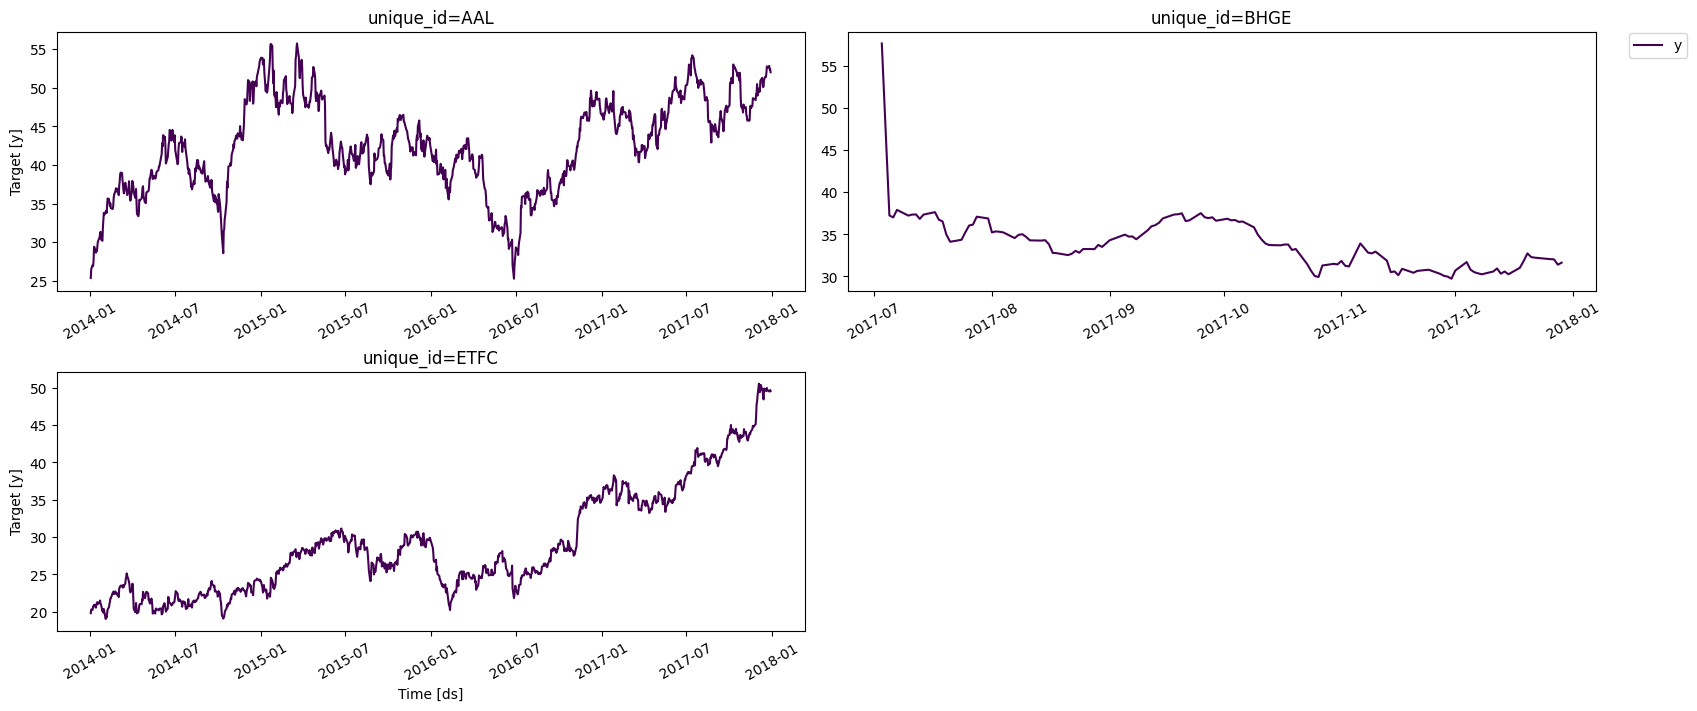

In [140]:
plot_series(df=df, ids=["AAL","BHGE","ETFC"], palette='viridis')

DECOMPOSITION INTO #TREND, #SEASONALITY AND #RESIDUAL

In [139]:
from statsmodels.tsa.seasonal import seasonal_decompose

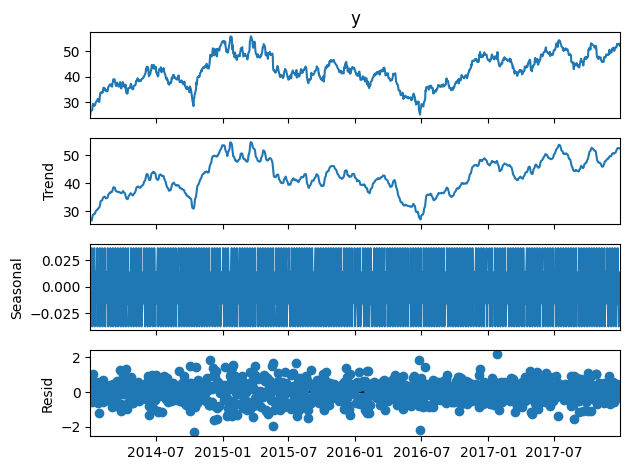

In [131]:

aal = df[df['unique_id'] == 'AAL'].copy()

aal = aal.sort_values('ds')
aal = aal.set_index('ds')

decomposition = seasonal_decompose(
    aal['y'],
    model='additive',
    period=5
)

decomposition.plot()

plt.tight_layout()
plt.show()

GENERATING A 5 DAY MOVING AVERAGE

In [132]:
df['moving_avg_5'] = (
    df.groupby('unique_id')['y']
      .transform(lambda x: x.rolling(window=5).mean())
)

PLOT OF THE 5 DAYS MOVING AVERAGES

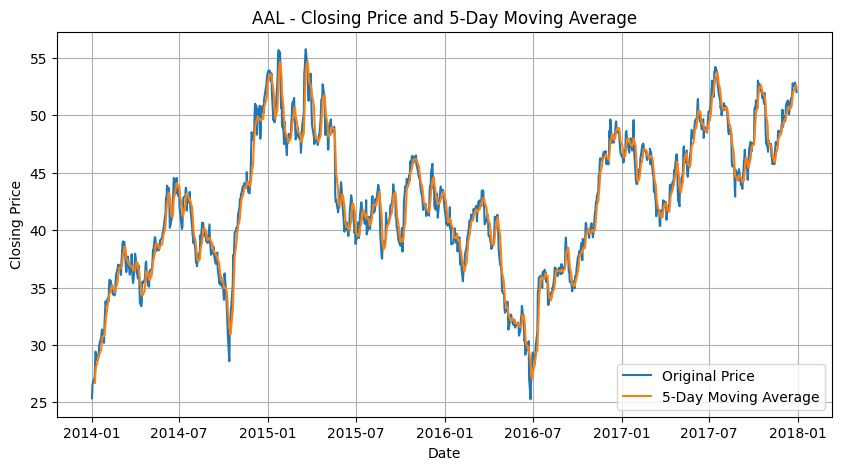

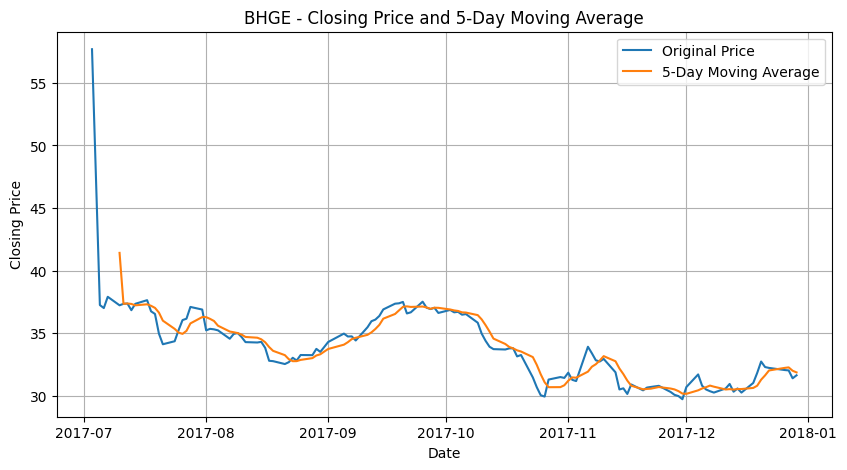

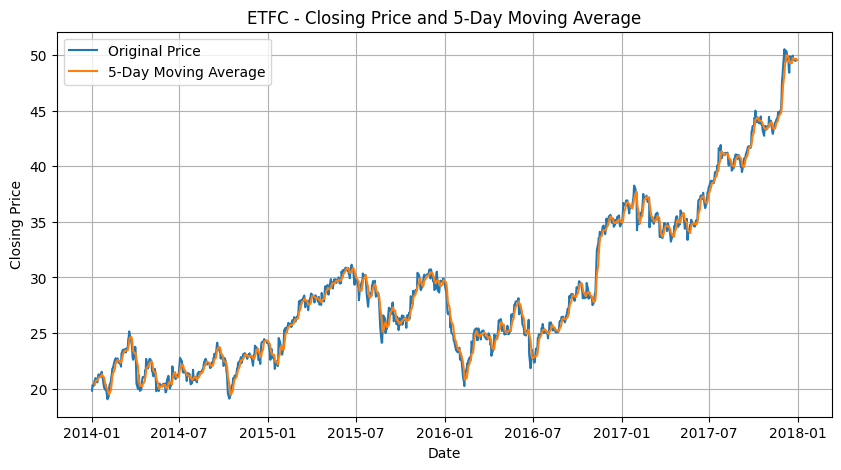

In [136]:
stocks = ['AAL', 'BHGE', 'ETFC']

for stock in stocks:
    stock_df = df[df['unique_id'] == stock]

    plt.figure(figsize=(10, 5))

    plt.plot(
        stock_df['ds'],
        stock_df['y'],
        label='Original Price'
    )

    plt.plot(
        stock_df['ds'],
        stock_df['moving_avg_5'],
        label='5-Day Moving Average'
    )

    plt.title(f'{stock} - Closing Price and 5-Day Moving Average')
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.legend()
    plt.grid(True)
    plt.show()
